In [1]:
# ============================================================
# ✅ 1. Install Required Libraries
# ============================================================
# Note: Run this cell first to install dependencies. No dependencies from other steps.

!pip install imbalanced-learn xgboost scikit-learn==1.5.0 seaborn matplotlib shap --quiet
print("✅ Libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 75.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.5.0 which is incompatible.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.5.0 which is incompatible.
✅ Libraries installed successfully!


In [2]:
# ============================================================
# ✅ 2. Import Packages
# ============================================================
# Note: Run after Step 1. No dependencies from other steps.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve, auc,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Handle class imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Misc
import warnings
warnings.filterwarnings("ignore")

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 600

# Create directory to save plots
import os
plot_dir = "/content/plots"
os.makedirs(plot_dir, exist_ok=True)
print(f"📁 Plots will be saved to: {plot_dir}")

📁 Plots will be saved to: /content/plots


In [3]:
# ============================================================
# ✅ 3. Load Dataset
# ============================================================
# Dependencies: None (assumes dataset at /content/Link1.csv)
# Outputs: df (DataFrame)

# Note: Update the path below if your dataset is not at /content/Link1.csv
df = pd.read_csv("/content/Final.csv")
print("Dataset shape:", df.shape)
print("\n" + "="*60)
print("COLUMN NAMES IN YOUR DATASET:")
print("="*60)
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

Dataset shape: (1205, 12)

COLUMN NAMES IN YOUR DATASET:
1. Age
2. Systolic BP
3. Diastolic
4. BS
5. Body Temp
6. BMI
7. Previous Complications
8. Preexisting Diabetes
9. Gestational Diabetes
10. Mental Health
11. Heart Rate
12. Risk Level


In [4]:
# ============================================================
# ✅ 4. Identify Target Column
# ============================================================
# Dependencies: df (from Step 3)
# Outputs: target_col, target_mapping (if target is categorical), df (updated with encoded target)

possible_target_names = ['RiskLevel', 'Risk Level', 'risk_level', 'Risk', 'risk',
                         'target', 'Target', 'label', 'Label', 'class', 'Class']

target_col = None
for col in possible_target_names:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    target_col = df.columns[-1]
    print(f"\n⚠️ Using last column as target: '{target_col}'")
else:
    print(f"\n✅ Target column identified: '{target_col}'")

# Define class labels (for summary report)
class_labels = df[target_col].unique()

# Encode target if needed
target_mapping = None
if df[target_col].dtype == 'object':
    le = LabelEncoder()
    df[target_col] = le.fit_transform(df[target_col])
    target_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\n✅ Target encoded. Mapping: {target_mapping}")


✅ Target column identified: 'Risk Level'

✅ Target encoded. Mapping: {'High': np.int64(0), 'Low': np.int64(1), nan: np.int64(2)}


In [5]:
# ============================================================
# ✅ 5. EXPLORATORY DATA ANALYSIS
# ============================================================
# Dependencies: df, target_col, plot_dir (from Steps 2, 3, 4)
# Outputs: None (prints EDA and saves plots)

print(f"\n{'='*60}")
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Dataset Overview
print("\n📊 Dataset Overview:")
display(df.head(10))
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nData Types:\n{df.dtypes}")

# Missing Values
print(f"\n{'='*60}")
print("MISSING VALUES")
print("="*60)
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("✅ No missing values found!")

# Statistical Summary
print(f"\n{'='*60}")
print("STATISTICAL SUMMARY")
print("="*60)
display(df.describe())

# Target Distribution
print(f"\n{'='*60}")
print(f"TARGET VARIABLE: {target_col}")
print("="*60)
print(f"Data type: {df[target_col].dtype}")
print(f"Unique values: {df[target_col].nunique()}")
print(f"\nValue counts:\n{df[target_col].value_counts()}")


EXPLORATORY DATA ANALYSIS

📊 Dataset Overview:


,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.00,100,18.0,1.0,1.0,0,1,80.0,0
1,22,110.0,70.0,7.10,98,20.4,0.0,0.0,0,0,74.0,1
2,27,110.0,70.0,7.50,98,23.0,1.0,0.0,0,0,72.0,1
3,20,100.0,70.0,7.20,98,21.2,0.0,0.0,0,0,74.0,1
4,20,90.0,60.0,7.50,98,19.7,0.0,0.0,0,0,74.0,1
5,22,120.0,70.0,7.01,98,24.0,0.0,0.0,0,0,76.0,1
6,20,110.0,70.0,9.00,102,17.6,0.0,1.0,0,0,78.0,0
7,23,110.0,80.0,7.00,98,21.3,0.0,0.0,0,0,74.0,1
8,22,90.0,60.0,6.40,98,22.0,0.0,0.0,0,0,72.0,1
9,26,110.0,70.0,12.00,100,30.2,1.0,1.0,1,1,80.0,0



Shape: 1205 rows × 12 columns

Data Types:
Age                         int64
Systolic BP               float64
Diastolic                 float64
BS                        float64
Body Temp                   int64
BMI                       float64
Previous Complications    float64
Preexisting Diabetes      float64
Gestational Diabetes        int64
Mental Health               int64
Heart Rate                float64
Risk Level                  int64
dtype: object

MISSING VALUES
Systolic BP                5
Diastolic                  4
BS                         2
BMI                       18
Previous Complications     2
Preexisting Diabetes       2
Heart Rate                 2
dtype: int64

STATISTICAL SUMMARY


,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
count,1205.000000,1200.000000,1201.000000,1203.000000,1205.000000,1187.000000,1203.000000,1203.000000,1205.000000,1205.00000,1203.000000,1205.000000
mean,27.731950,116.819167,77.166528,7.501064,98.395851,23.315080,0.175395,0.288446,0.117842,0.33444,75.817124,0.621577
std,12.571074,18.715502,14.305148,3.049522,1.088363,3.875682,0.380463,0.453228,0.322555,0.47199,7.227338,0.515087
min,10.000000,70.000000,40.000000,3.000000,97.000000,0.000000,0.000000,0.000000,0.000000,0.00000,58.000000,0.000000
25%,21.000000,100.000000,65.000000,6.000000,98.000000,20.450000,0.000000,0.000000,0.000000,0.00000,70.000000,0.000000
50%,25.000000,120.000000,80.000000,6.900000,98.000000,23.000000,0.000000,0.000000,0.000000,0.00000,76.000000,1.000000
75%,32.000000,130.000000,90.000000,7.900000,98.000000,25.000000,0.000000,1.000000,0.000000,1.00000,80.000000,1.000000
max,325.000000,200.000000,140.000000,19.000000,103.000000,37.000000,1.000000,1.000000,1.000000,1.00000,92.000000,2.000000



TARGET VARIABLE: Risk Level
Data type: int64
Unique values: 3

Value counts:
Risk Level
1    713
0    474
2     18
Name: count, dtype: int64



GENERATING VISUALIZATIONS
✅ Saved: 01_target_distribution_bar.png


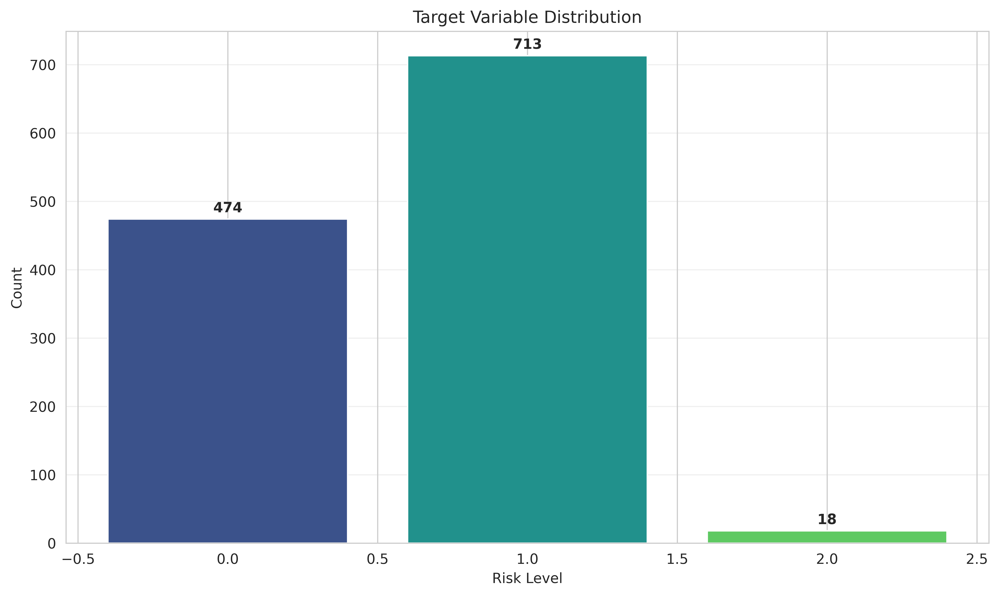

✅ Saved: 01_target_distribution_pie.png


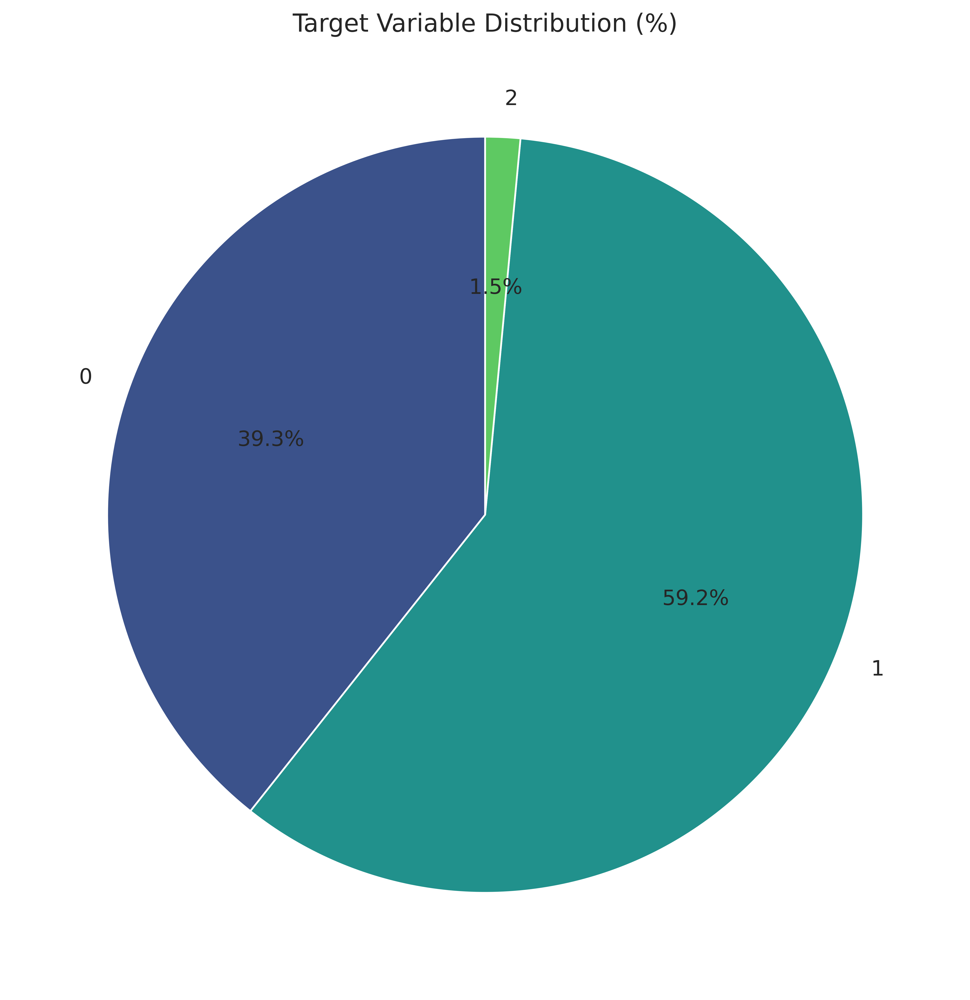

In [6]:
# ============================================================
# ✅ 6. VISUALIZATIONS - Data Distribution
# ============================================================
# Dependencies: df, target_col, plot_dir (from Steps 2, 3, 4)
# Outputs: None (saves plots)

print(f"\n{'='*60}")
print("GENERATING VISUALIZATIONS")
print("="*60)

# 1. Target Distribution Bar Plot
plt.figure(figsize=(10, 6))
target_counts = df[target_col].value_counts().sort_index()
bars = plt.bar(target_counts.index, target_counts.values, color=sns.color_palette("viridis", len(target_counts)))
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.title('Target Variable Distribution')
for i, v in enumerate(target_counts.values):
    plt.text(target_counts.index[i], v + 10, str(v), ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{plot_dir}/01_target_distribution_bar.png", dpi=600, bbox_inches='tight')
print("✅ Saved: 01_target_distribution_bar.png")
plt.show()

# 2. Target Distribution Pie Chart
plt.figure(figsize=(8, 8))
target_counts = df[target_col].value_counts().sort_index()
plt.pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette("viridis", len(target_counts)), startangle=90,
        textprops={'fontsize': 12})
plt.title('Target Variable Distribution (%)', fontsize=14)
plt.tight_layout()
plt.savefig(f"{plot_dir}/01_target_distribution_pie.png", dpi=300, bbox_inches='tight')
print("✅ Saved: 01_target_distribution_pie.png")
plt.show()

In [7]:
# 2. Feature Distributions
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target_col in numeric_features:
    numeric_features.remove(target_col)

if len(numeric_features) > 0:
    n_features = len(numeric_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

    for idx, col in enumerate(numeric_features):
        sns.histplot(data=df, x=col, hue=target_col, kde=True, ax=axes[idx], palette='viridis')
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')

    for idx in range(n_features, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(f"{plot_dir}/02_feature_distributions.png", dpi=300, bbox_inches='tight')
    print("✅ Saved: 02_feature_distributions.png")
    plt.show()


Output hidden; open in https://colab.research.google.com to view.

✅ Saved: 03_correlation_heatmap.png


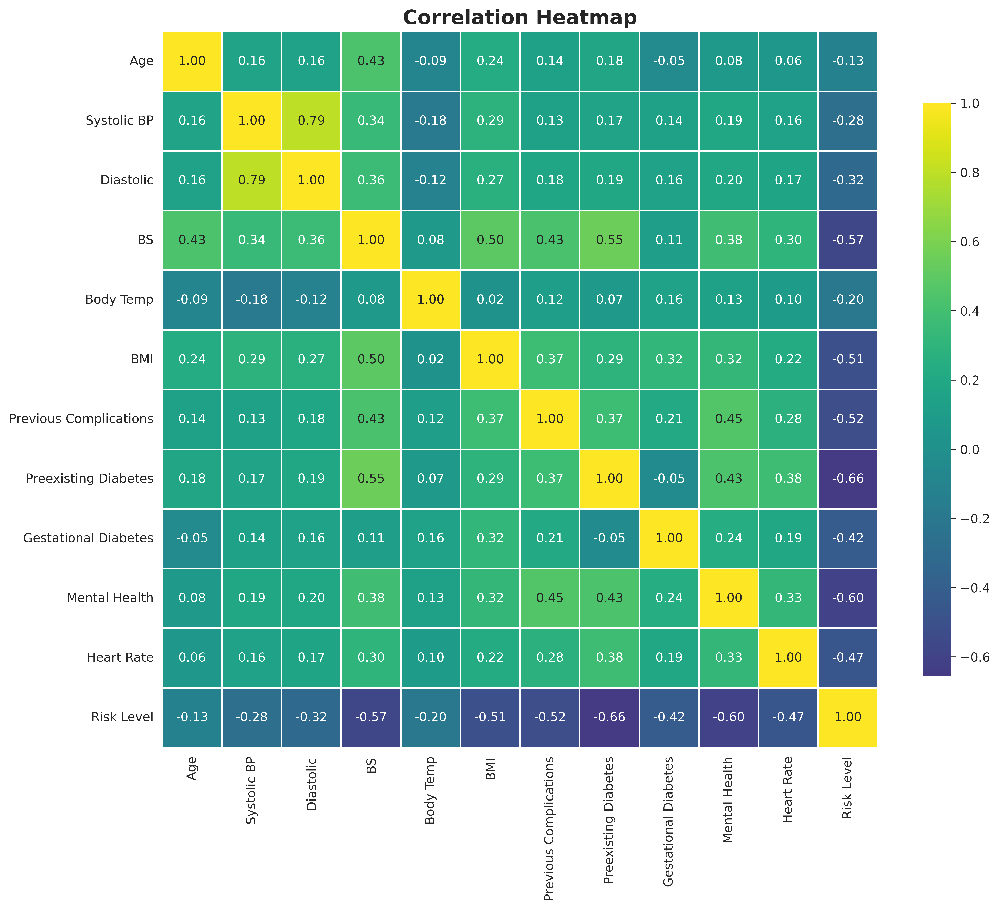

In [8]:
# 3. Correlation Heatmap
X = df.drop(columns=[target_col])
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

if len(numeric_cols) > 1:
    plt.figure(figsize=(12, 10))
    correlation_matrix = df[numeric_cols + [target_col]].corr()
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='viridis',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})#Add mask=mask with (,) to get only lower triangle
    plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{plot_dir}/03_correlation_heatmap.png", dpi=600, bbox_inches='tight')
    print("✅ Saved: 03_correlation_heatmap.png")
    plt.show()


In [9]:
# 4. Box Plots for Outlier Detection
if len(numeric_features) > 0:
    n_features = len(numeric_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

    for idx, col in enumerate(numeric_features):
        sns.boxplot(data=df, x=target_col, y=col, ax=axes[idx], palette='Set2')
        axes[idx].set_title(f'Box Plot: {col} by Risk Level')
        axes[idx].set_xlabel('Risk Level')
        axes[idx].set_ylabel(col)

    for idx in range(n_features, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(f"{plot_dir}/04_boxplots_outliers.png", dpi=300, bbox_inches='tight')
    print("✅ Saved: 04_boxplots_outliers.png")
    plt.show()

✅ Saved: 04_boxplots_outliers.png


In [10]:
# ============================================================
# ✅ 7. Prepare Data for Modeling
# ============================================================
# Dependencies: df, target_col (from Steps 3, 4)
# Outputs: X, y, X_train, X_test, y_train, y_test, numeric_cols, categorical_cols, n_classes

y = df[target_col].values
X = df.drop(columns=[target_col])
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nFeature Columns:")
print(f"  Numeric ({len(numeric_cols)}): {numeric_cols}")
print(f"  Categorical ({len(categorical_cols)}): {categorical_cols}")

n_classes = len(np.unique(y))
print(f"\nNumber of classes: {n_classes}")
print(f"Class distribution: {np.bincount(y)}")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Feature Columns:
  Numeric (11): ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health', 'Heart Rate']
  Categorical (0): []

Number of classes: 3
Class distribution: [474 713  18]

Train set: 964 samples
Test set: 241 samples


In [11]:
# ============================================================
# ✅ 8. Preprocessing Pipeline
# ============================================================
# Dependencies: numeric_cols, categorical_cols (from Step 7)
# Outputs: preprocessor

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', ohe)
])

transformers = [('num', numeric_transformer, numeric_cols)]
if len(categorical_cols) > 0:
    transformers.append(('cat', categorical_transformer, categorical_cols))

preprocessor = ColumnTransformer(transformers=transformers)
print("✅ Preprocessing pipeline defined!")

✅ Preprocessing pipeline defined!


In [12]:
# ============================================================
# ✅ 9. Define Models
# ============================================================
# Dependencies: None
# Outputs: models (dictionary of model instances)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(probability=True, kernel='rbf', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(algorithm='SAMME', random_state=42),
    "XGBoost": XGBClassifier(
        use_label_encoder=False, eval_metric='logloss',
        learning_rate=0.05, n_estimators=200, max_depth=4, random_state=42
    ),
    "ANN": MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                         solver='adam', max_iter=500, random_state=42)
}
print("✅ Models defined!")

✅ Models defined!


In [13]:
# ============================================================
# ✅ 10. K-Fold CV with Multiple Metrics
# ============================================================
# Dependencies: X, y, n_classes, models, preprocessor (from Steps 7, 9, 8)
# Outputs: results, all_metrics

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

if n_classes == 2:
    scoring_metric = 'roc_auc'
    metric_name = "ROC-AUC"
else:
    scoring_metric = 'f1_weighted'
    metric_name = "F1-Score (Weighted)"

results = {}
all_metrics = []

print(f"\n{'='*60}")
print(f"MODEL PERFORMANCE (5-Fold Cross-Validation)")
print("="*60 + "\n")

for name, model in models.items():
    try:
        pipe = ImbPipeline([
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('model', model)
        ])

        scores = cross_val_score(pipe, X, y, cv=cv, scoring=scoring_metric, error_score='raise')
        results[name] = scores

        mean_score = scores.mean()
        std_score = scores.std()

        all_metrics.append({
            'Model': name,
            'Mean Score': mean_score,
            'Std Dev': std_score,
            'Min Score': scores.min(),
            'Max Score': scores.max()
        })

        print(f"{name:25s} {metric_name} = {mean_score:.4f} (+/- {std_score:.4f})")
    except Exception as e:
        print(f"{name:25s} ❌ Failed: {str(e)[:50]}")
        continue


MODEL PERFORMANCE (5-Fold Cross-Validation)

Logistic Regression       F1-Score (Weighted) = 0.8738 (+/- 0.0116)
Decision Tree             F1-Score (Weighted) = 0.9258 (+/- 0.0074)
Random Forest             F1-Score (Weighted) = 0.9598 (+/- 0.0078)
SVM                       F1-Score (Weighted) = 0.8880 (+/- 0.0205)
KNN                       F1-Score (Weighted) = 0.8966 (+/- 0.0080)
Naive Bayes               F1-Score (Weighted) = 0.9108 (+/- 0.0403)
Gradient Boosting         F1-Score (Weighted) = 0.9594 (+/- 0.0049)
AdaBoost                  F1-Score (Weighted) = 0.8759 (+/- 0.0780)
XGBoost                   F1-Score (Weighted) = 0.9556 (+/- 0.0096)
ANN                       F1-Score (Weighted) = 0.9442 (+/- 0.0051)


In [14]:
# ============================================================
# ✅ 11. MODEL COMPARISON TABLE
# ============================================================
# Dependencies: all_metrics, plot_dir (from Steps 10, 2)
# Outputs: metrics_df (saved as CSV)

if len(all_metrics) > 0:
    metrics_df = pd.DataFrame(all_metrics).sort_values('Mean Score', ascending=False)
    print(f"\n{'='*60}")
    print("MODEL COMPARISON TABLE")
    print("="*60)
    display(metrics_df)

    metrics_df.to_csv("/content/model_comparison_table.csv", index=False)
    print("\n✅ Comparison table saved to: /content/model_comparison_table.csv")


MODEL COMPARISON TABLE


,Model,Mean Score,Std Dev,Min Score,Max Score
2,Random Forest,0.959810,0.007780,0.950021,0.973108
6,Gradient Boosting,0.959373,0.004938,0.952009,0.966888
8,XGBoost,0.955562,0.009607,0.943686,0.970998
9,ANN,0.944205,0.005084,0.935319,0.950125
1,Decision Tree,0.925801,0.007393,0.916382,0.936796
5,Naive Bayes,0.910774,0.040327,0.830688,0.939729
4,KNN,0.896648,0.007975,0.885197,0.905033
3,SVM,0.888040,0.020495,0.852769,0.910456
7,AdaBoost,0.875925,0.077990,0.728146,0.937553
0,Logistic Regression,0.873807,0.011611,0.851563,0.884895



✅ Comparison table saved to: /content/model_comparison_table.csv


✅ Saved: 05_model_comparison_bar.png


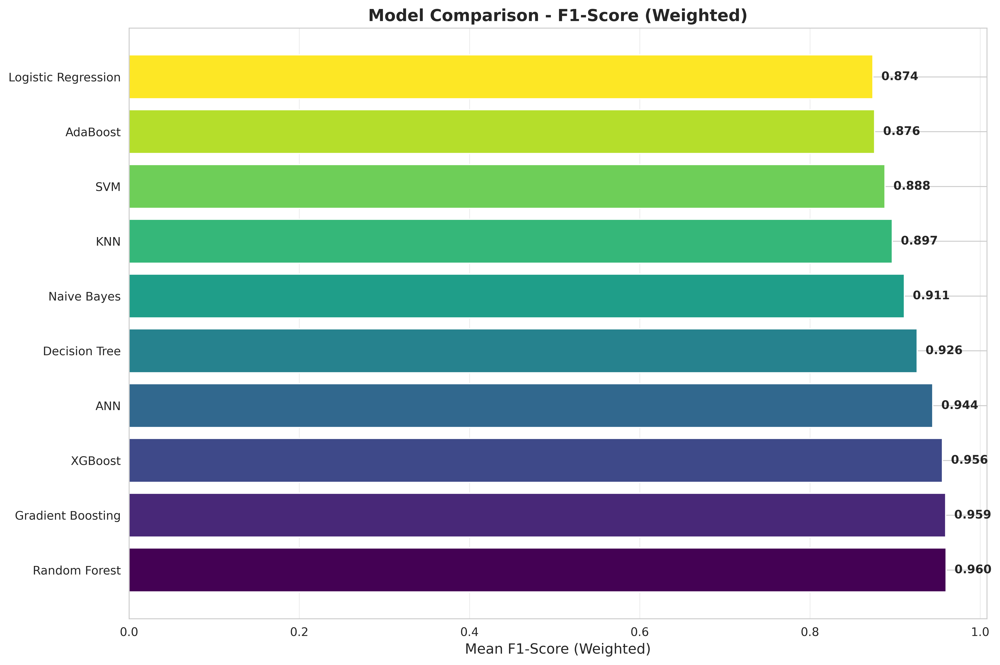

✅ Saved: 05_model_comparison_boxplot.png


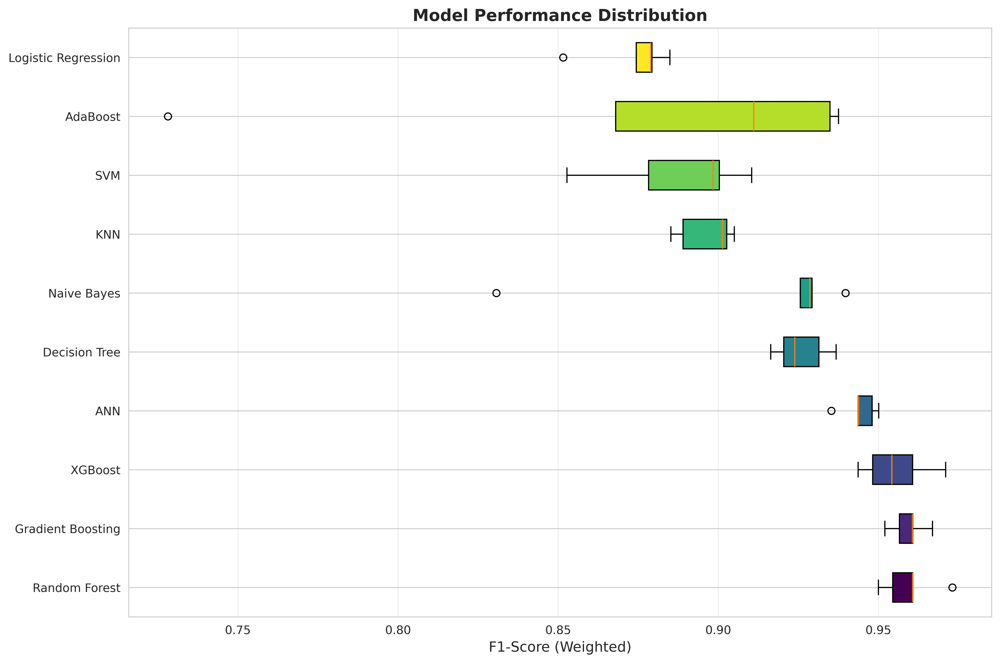

✅ Saved: 06_cv_heatmap.png


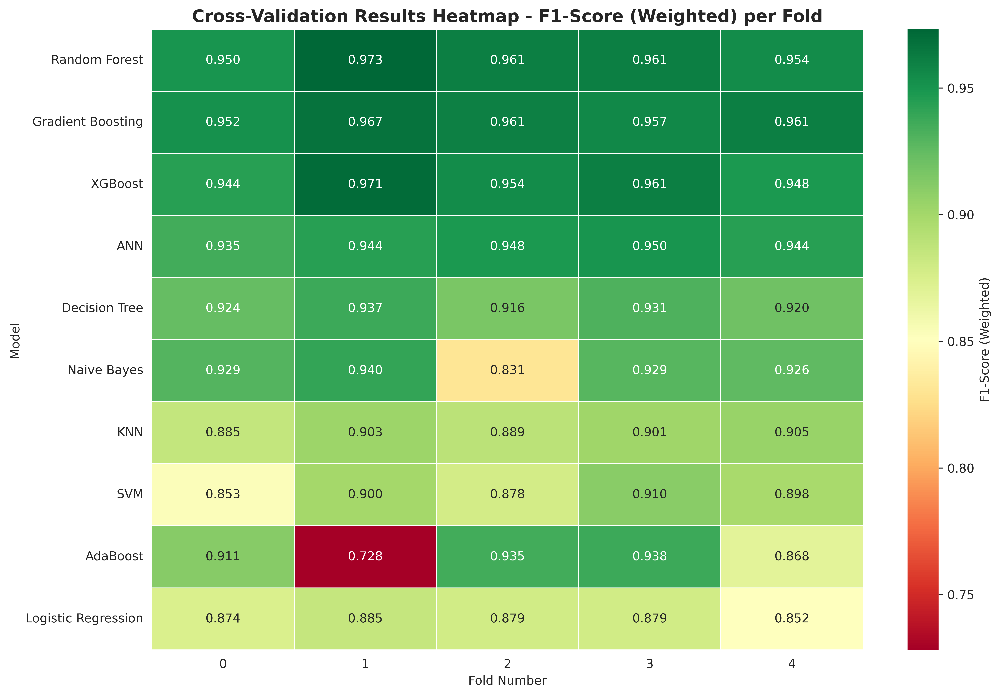

In [15]:
# ============================================================
# ✅ 12. VISUALIZATIONS - Model Comparison
# ============================================================
# Dependencies: results, plot_dir, metric_name (from Steps 10, 2, 10)
# Outputs: None (saves plots)

if len(results) > 0:
    results_df = pd.DataFrame(results)
    mean_scores = results_df.mean().sort_values(ascending=False)

    # 1. Bar Chart Comparison
    plt.figure(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0, 1, len(mean_scores)))
    bars = plt.barh(range(len(mean_scores)), mean_scores.values, color=colors)
    plt.yticks(range(len(mean_scores)), mean_scores.index)
    plt.xlabel(f"Mean {metric_name}", fontsize=12)
    plt.title(f"Model Comparison - {metric_name}", fontsize=14, fontweight='bold')

    for i, (v, name) in enumerate(zip(mean_scores.values, mean_scores.index)):
        plt.text(v + 0.01, i, f"{v:.3f}", va='center', fontsize=10, fontweight='bold')

    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{plot_dir}/05_model_comparison_bar.png", dpi=300, bbox_inches='tight')
    print("✅ Saved: 05_model_comparison_bar.png")
    plt.show()

    # 2. Box Plot Comparison
    plt.figure(figsize=(12, 8))
    results_df_sorted = results_df[mean_scores.index]
    colors = plt.cm.viridis(np.linspace(0, 1, len(mean_scores)))

    bp = plt.boxplot([results_df_sorted[col] for col in results_df_sorted.columns],
                     labels=results_df_sorted.columns, patch_artist=True, vert=False)

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    plt.xlabel(f"{metric_name}", fontsize=12)
    plt.title(f"Model Performance Distribution", fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{plot_dir}/05_model_comparison_boxplot.png", dpi=300, bbox_inches='tight')
    print("✅ Saved: 05_model_comparison_boxplot.png")
    plt.show()

    # Heatmap of All Fold Results
    plt.figure(figsize=(12, 8))
    results_df_sorted = results_df[mean_scores.index]
    sns.heatmap(results_df_sorted.T, annot=True, fmt='.3f', cmap='RdYlGn',
                cbar_kws={'label': metric_name}, linewidths=0.5)
    plt.title(f'Cross-Validation Results Heatmap - {metric_name} per Fold',
              fontsize=14, fontweight='bold')
    plt.xlabel('Fold Number')
    plt.ylabel('Model')
    plt.tight_layout()
    plt.savefig(f"{plot_dir}/06_cv_heatmap.png", dpi=300, bbox_inches='tight')
    print("✅ Saved: 06_cv_heatmap.png")
    plt.show()

In [16]:
# ============================================================
# ✅ 12b. Statistical Significance Testing (Paired t-test)
# ============================================================
# Dependencies: results, mean_scores, cv, metric_name (from Step 10)
# Outputs: Prints p-value for top 2 models and publication-ready text
# NOTE: Uses the SAME fold scores from Step 10 to guarantee consistency
#       with the model comparison table. No re-running of CV.

from scipy.stats import ttest_rel
import numpy as np

# Get the two best models from the already-computed mean_scores
sorted_models = sorted(mean_scores.items(), key=lambda x: x[1], reverse=True)
best_model_1_name = sorted_models[0][0]
best_model_2_name = sorted_models[1][0]

# Pull fold scores directly from Step 10 results — no re-run, no data mismatch
scores_1 = results[best_model_1_name]
scores_2 = results[best_model_2_name]

print(f"\n{'='*60}")
print("📊 STATISTICAL SIGNIFICANCE TEST (Paired t-test)")
print("="*60)
print(f"Using fold scores already computed in Step 10 (consistent with comparison table).")

print(f"\nModel 1: {best_model_1_name}")
print(f"  Mean {metric_name}: {np.mean(scores_1):.4f} (±{np.std(scores_1):.4f})")
print(f"  Fold scores: {scores_1}")

print(f"\nModel 2: {best_model_2_name}")
print(f"  Mean {metric_name}: {np.mean(scores_2):.4f} (±{np.std(scores_2):.4f})")
print(f"  Fold scores: {scores_2}")

# Perform paired t-test
t_stat, p_value = ttest_rel(scores_1, scores_2)

print(f"\n{'='*60}")
print("STATISTICAL COMPARISON RESULTS")
print("="*60)
print(f"\nDifference (Model1 - Model2): {np.mean(scores_1) - np.mean(scores_2):.4f}")
print(f"\nPaired t-test Results:")
print(f"  T-statistic: {t_stat:.4f}")
print(f"  P-value: {p_value:.6f}")
print(f"  Degrees of freedom: {len(scores_1) - 1}")

# Statistical interpretation
if p_value < 0.001:
    significance = "HIGHLY SIGNIFICANT (p < 0.001)"
    symbol = "***"
elif p_value < 0.01:
    significance = "VERY SIGNIFICANT (p < 0.01)"
    symbol = "**"
elif p_value < 0.05:
    significance = "STATISTICALLY SIGNIFICANT (p < 0.05)"
    symbol = "*"
elif p_value < 0.10:
    significance = "MARGINALLY SIGNIFICANT (p < 0.10)"
    symbol = "†"
else:
    significance = "NOT SIGNIFICANT (p ≥ 0.10)"
    symbol = "ns"

print(f"\n✅ Result: {significance}")

if p_value < 0.05:
    print(f"   → {best_model_1_name} performs significantly better than {best_model_2_name}")
elif p_value < 0.10:
    print(f"   → Weak evidence of difference between models")
else:
    print(f"   → No significant difference; models are statistically equivalent")
    print(f"   → Choose based on other factors (speed, interpretability, etc.)")

print("="*60)

# Generate publication-ready text
print("\n" + "="*60)
print("📄 TEXT FOR PAPER (copy this):")
print("="*60)

paper_text = f"""
To assess whether the performance improvement of {best_model_1_name} over
competing models is statistically significant, a paired t-test was conducted
on the fold-wise weighted F1-scores obtained from {cv.get_n_splits()}-fold
cross-validation between {best_model_1_name} and the second-best model
({best_model_2_name}). """

if p_value < 0.05:
    paper_text += f"""The analysis revealed that {best_model_1_name}
significantly outperformed {best_model_2_name} (mean F1 = {np.mean(scores_1):.4f}
± {np.std(scores_1):.4f} vs {np.mean(scores_2):.4f} ± {np.std(scores_2):.4f},
t({len(scores_1)-1}) = {t_stat:.2f}, p = {p_value:.4f}), supporting
the selection of {best_model_1_name} as the optimal model for maternal health
risk prediction."""
else:
    paper_text += f"""While {best_model_1_name} achieved a numerically higher
mean F1-score ({np.mean(scores_1):.4f} ± {np.std(scores_1):.4f} vs
{np.mean(scores_2):.4f} ± {np.std(scores_2):.4f}), the difference was not
statistically significant (t({len(scores_1)-1}) = {t_stat:.2f}, p = {p_value:.3f}).
{best_model_1_name} was selected as the final model based on its marginally
superior performance and other favorable characteristics such as robustness
and interpretability."""

print(paper_text)
print("\n" + "="*60)

# Save results to file
with open(f"{plot_dir}/statistical_test_results.txt", "w") as f:
    f.write(f"Statistical Significance Test Results\n")
    f.write("="*60 + "\n\n")
    f.write(f"Model 1: {best_model_1_name}\n")
    f.write(f"  Mean {metric_name}: {np.mean(scores_1):.4f} ± {np.std(scores_1):.4f}\n")
    f.write(f"  Fold scores: {scores_1}\n\n")
    f.write(f"Model 2: {best_model_2_name}\n")
    f.write(f"  Mean {metric_name}: {np.mean(scores_2):.4f} ± {np.std(scores_2):.4f}\n")
    f.write(f"  Fold scores: {scores_2}\n\n")
    f.write(f"Paired t-test:\n")
    f.write(f"  T-statistic: {t_stat:.4f}\n")
    f.write(f"  P-value: {p_value:.6f}\n")
    f.write(f"  Significance: {significance}\n\n")
    f.write(f"Publication Text:\n")
    f.write(f"{'-'*60}\n")
    f.write(paper_text)

print(f"✅ Results saved to: {plot_dir}/statistical_test_results.txt")


📊 STATISTICAL SIGNIFICANCE TEST (Paired t-test)
Using fold scores already computed in Step 10 (consistent with comparison table).

Model 1: Random Forest
  Mean F1-Score (Weighted): 0.9598 (±0.0078)
  Fold scores: [0.95002108 0.97310841 0.96073272 0.9607007  0.95448788]

Model 2: Gradient Boosting
  Mean F1-Score (Weighted): 0.9594 (±0.0049)
  Fold scores: [0.95200905 0.96688817 0.96063187 0.95659278 0.96074385]

STATISTICAL COMPARISON RESULTS

Difference (Model1 - Model2): 0.0004

Paired t-test Results:
  T-statistic: 0.1977
  P-value: 0.852909
  Degrees of freedom: 4

✅ Result: NOT SIGNIFICANT (p ≥ 0.10)
   → No significant difference; models are statistically equivalent
   → Choose based on other factors (speed, interpretability, etc.)

📄 TEXT FOR PAPER (copy this):

To assess whether the performance improvement of Random Forest over
competing models is statistically significant, a paired t-test was conducted
on the fold-wise weighted F1-scores obtained from 5-fold
cross-validation

In [17]:
# ============================================================
# ✅ 13. Train and Evaluate Best Model
# ============================================================
# Dependencies: results, models, preprocessor, X_train, X_test, y_train, y_test, metric_name (from Steps 10, 9, 8, 7, 10)
# Outputs: final_pipe, y_pred, y_prob, best_model_name, accuracy, precision, recall, f1, mean_scores

if len(results) > 0:
    mean_scores = pd.DataFrame(results).mean().sort_values(ascending=False)
    best_model_name = mean_scores.idxmax()
    best_model = models[best_model_name]

    print(f"\n{'='*60}")
    print(f"🏆 BEST MODEL: {best_model_name}")
    print(f"   Cross-Validation {metric_name}: {mean_scores[best_model_name]:.4f}")
    print("="*60)

    final_pipe = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', best_model)
    ])

    final_pipe.fit(X_train, y_train)
    y_pred = final_pipe.predict(X_test)
    y_prob = final_pipe.predict_proba(X_test)

    # Detailed Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n📊 Test Set Performance:")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")

    # Classification Report
    print("\n📋 Detailed Classification Report:")
    print(classification_report(y_test, y_pred))


🏆 BEST MODEL: Random Forest
   Cross-Validation F1-Score (Weighted): 0.9598

📊 Test Set Performance:
   Accuracy:  0.9793
   Precision: 0.9713
   Recall:    0.9793
   F1-Score:  0.9752

📋 Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        95
           1       0.97      0.99      0.98       143
           2       0.00      0.00      0.00         3

    accuracy                           0.98       241
   macro avg       0.66      0.66      0.66       241
weighted avg       0.97      0.98      0.98       241



✅ Saved: 07_confusion_matrix.png


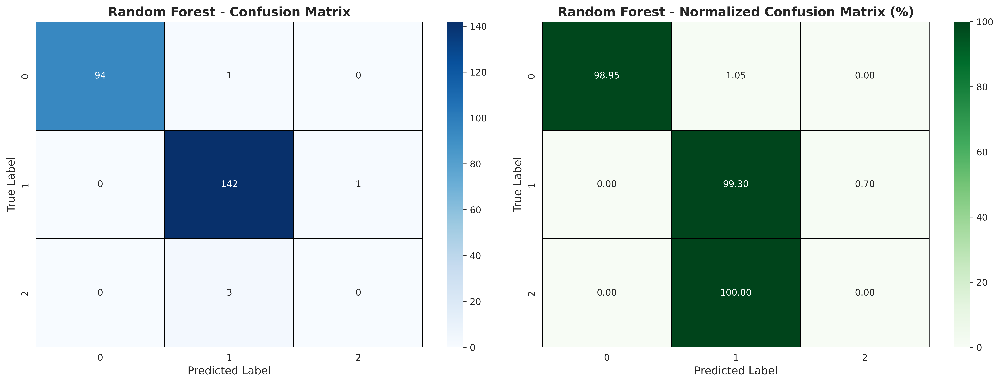

In [18]:
# ============================================================
# ✅ 14. BEST MODEL VISUALIZATIONS
# ============================================================
# Dependencies: y_test, y_pred, y_prob, best_model_name, n_classes, plot_dir (from Steps 13, 7, 2)
# Outputs: None (saves plots)

# Ensure necessary imports are available
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=axes[0],
            linewidths=1, linecolor='black')
axes[0].set_title(f"{best_model_name} - Confusion Matrix", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Predicted Label", fontsize=12)
axes[0].set_ylabel("True Label", fontsize=12)

# Normalized Confusion Matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm * 100, annot=True, fmt='.2f', cmap='Greens', cbar=True, ax=axes[1],
            linewidths=1, linecolor='black')
axes[1].set_title(f"{best_model_name} - Normalized Confusion Matrix (%)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Predicted Label", fontsize=12)
axes[1].set_ylabel("True Label", fontsize=12)

plt.tight_layout()
plt.savefig(f"{plot_dir}/07_confusion_matrix.png", dpi=300, bbox_inches='tight')
print("✅ Saved: 07_confusion_matrix.png")
plt.show()

✅ Saved: 08_roc_curve.png


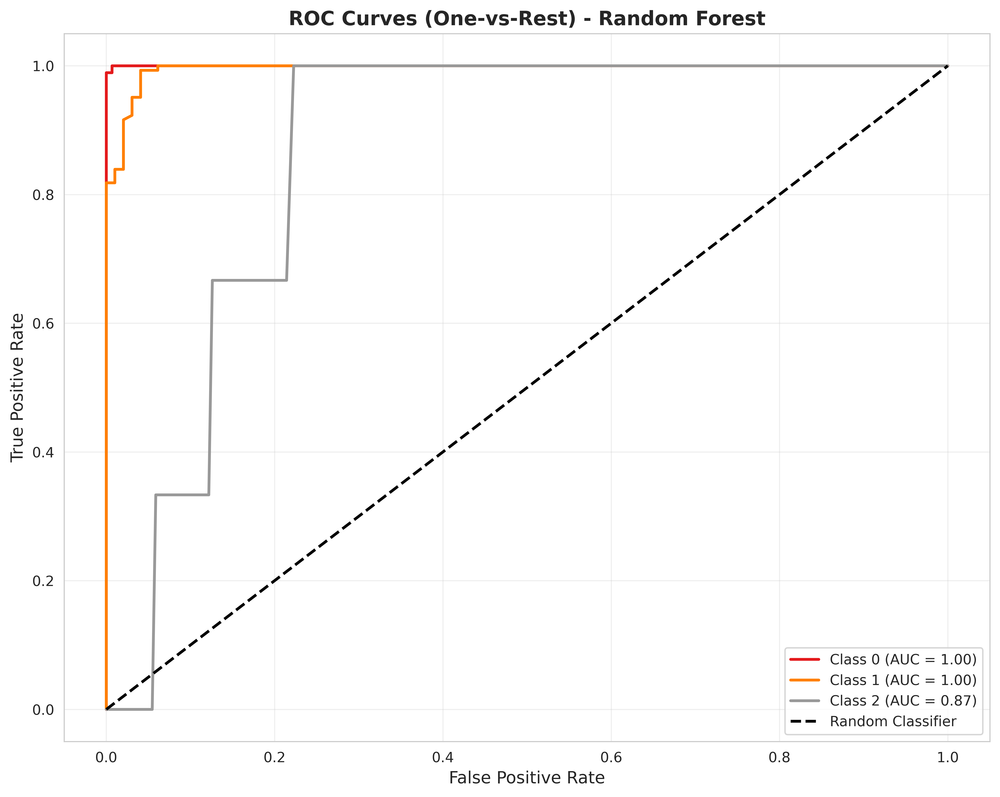


🎯 Test Set ROC-AUC (Weighted OvR): 0.9954


In [19]:
# 2. ROC Curves
if n_classes == 2:
    # Binary Classification ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc:.3f})",
             linewidth=3, color='#2E86AB')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
    plt.fill_between(fpr, tpr, alpha=0.2, color='#2E86AB')
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title(f"ROC Curve - {best_model_name}", fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{plot_dir}/08_roc_curve.png", dpi=300, bbox_inches='tight')
    print("✅ Saved: 08_roc_curve.png")
    plt.show()

    print(f"\n🎯 Test Set ROC-AUC: {roc_auc:.4f}")
else:
    # Multiclass ROC
    y_test_bin = label_binarize(y_test, classes=np.unique(y))

    plt.figure(figsize=(10, 8))
    colors = plt.cm.Set1(np.linspace(0, 1, n_classes))

    for i, color in enumerate(colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, linewidth=2,
                 label=f'Class {i} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title(f"ROC Curves (One-vs-Rest) - {best_model_name}", fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{plot_dir}/08_roc_curve.png", dpi=300, bbox_inches='tight')
    print("✅ Saved: 08_roc_curve.png")
    plt.show()

    try:
        roc_auc_weighted = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
        print(f"\n🎯 Test Set ROC-AUC (Weighted OvR): {roc_auc_weighted:.4f}")
    except:
        pass

✅ Saved: 09_prediction_distribution.png


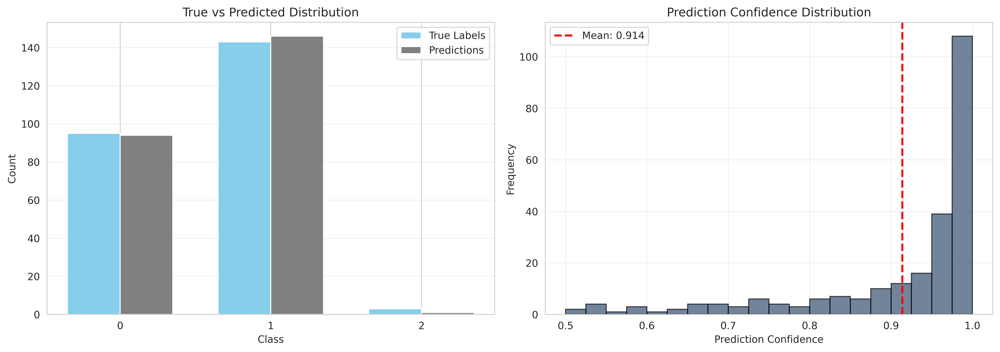


✅ ANALYSIS COMPLETE!
📁 Results saved to /content/model_comparison_table.csv


In [20]:
# 3. Prediction Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pred_counts = pd.Series(y_pred).value_counts().sort_index()
true_counts = pd.Series(y_test).value_counts().sort_index()

x = np.arange(len(true_counts))
width = 0.35

axes[0].bar(x - width/2, true_counts.values, width, label='True Labels', color='skyblue')
axes[0].bar(x + width/2, pred_counts.values, width, label='Predictions', color='grey')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_title('True vs Predicted Distribution')
axes[0].set_xticks(x)
axes[0].set_xticklabels(true_counts.index)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Prediction Confidence
confidence = np.max(y_prob, axis=1)
axes[1].hist(confidence, bins=20, color='#355070', alpha=0.7, edgecolor='black')
axes[1].axvline(confidence.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {confidence.mean():.3f}')
axes[1].set_xlabel('Prediction Confidence')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Prediction Confidence Distribution')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{plot_dir}/09_prediction_distribution.png", dpi=300, bbox_inches='tight')
print("✅ Saved: 09_prediction_distribution.png")
plt.show()

print("\n✅ ANALYSIS COMPLETE!")
print(f"📁 Results saved to /content/model_comparison_table.csv")


🌳 Extracting Feature Importance from Random Forest...

Top 11 Important Features:


,Feature,Importance
0,BMI,0.160033
1,BS,0.144575
2,Heart Rate,0.141360
3,Preexisting Diabetes,0.134560
4,Diastolic,0.094266
5,Age,0.075357
6,Mental Health,0.074001
7,Systolic BP,0.067988
8,Gestational Diabetes,0.065905
9,Previous Complications,0.023331


✅ Feature importance saved to: /content/feature_importance.csv
✅ Saved: 10_feature_importance.png


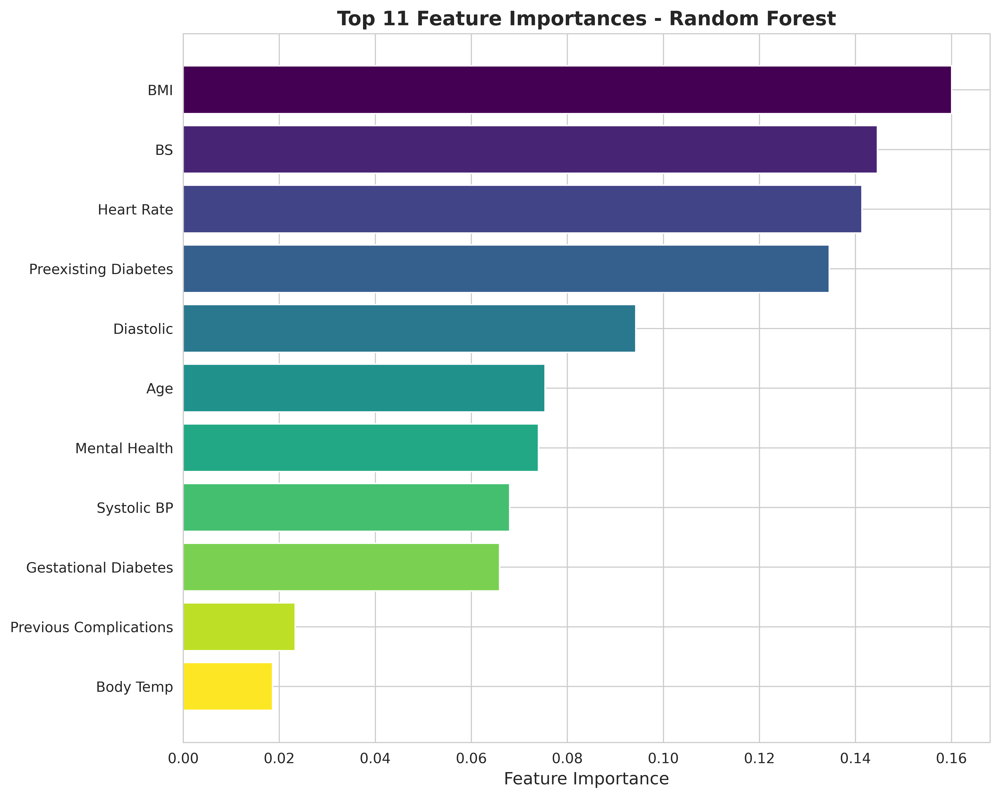

✅ Saved: 11_cumulative_importance.png


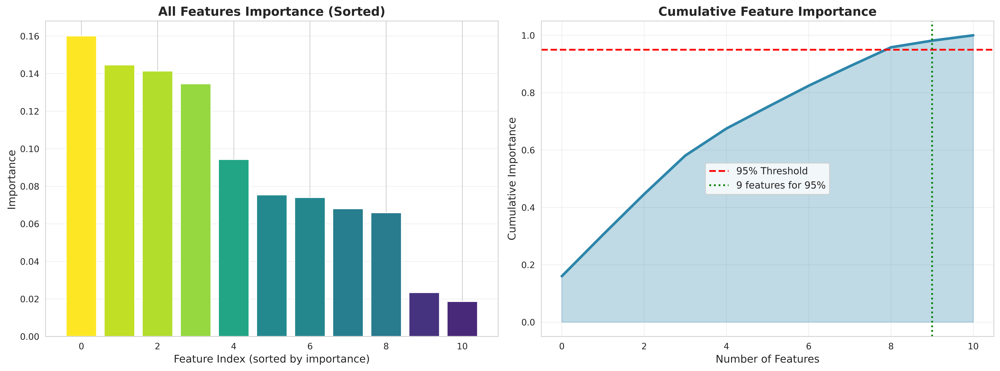


📊 9 features account for 95% of total importance


In [21]:
# ============================================================
# ✅ 15. FEATURE IMPORTANCE ANALYSIS
# ============================================================
# Dependencies: final_pipe, X_train, X_test, y_train, numeric_cols, categorical_cols, best_model_name, plot_dir (from Steps 13, 7, 2)
# Outputs: importance_df (saved as CSV, if tree-based model)

# Get feature names after preprocessing
feature_names = []
feature_names.extend(numeric_cols)

# Categorical features (one-hot encoded)
if len(categorical_cols) > 0:
    try:
        encoder = final_pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
        cat_features = encoder.get_feature_names_out(categorical_cols)
        feature_names.extend(cat_features)
    except:
        feature_names.extend(categorical_cols)

# Transform data for feature importance
X_train_transformed = final_pipe.named_steps['preprocessor'].transform(X_train)
X_test_transformed = final_pipe.named_steps['preprocessor'].transform(X_test)

# After SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_transformed, y_train)

# 1. Tree-based Feature Importance (if applicable)
tree_based_models = ['Decision Tree', 'Random Forest', 'Gradient Boosting',
                     'AdaBoost', 'XGBoost']

if best_model_name in tree_based_models:
    print(f"\n🌳 Extracting Feature Importance from {best_model_name}...")

    model = final_pipe.named_steps['model']

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]

        top_n = min(20, len(feature_names))
        top_indices = indices[:top_n]

        importance_df = pd.DataFrame({
            'Feature': [feature_names[i] for i in top_indices],
            'Importance': importances[top_indices]
        })

        print(f"\nTop {top_n} Important Features:")
        display(importance_df)

        importance_df.to_csv("/content/feature_importance.csv", index=False)
        print("✅ Feature importance saved to: /content/feature_importance.csv")

        # Visualization 1: Horizontal Bar Chart
        plt.figure(figsize=(10, 8))
        colors = plt.cm.viridis(np.linspace(0, 1, len(top_indices)))
        plt.barh(range(len(top_indices)), importances[top_indices], color=colors)
        plt.yticks(range(len(top_indices)), [feature_names[i] for i in top_indices])
        plt.xlabel('Feature Importance', fontsize=12)
        plt.title(f'Top {top_n} Feature Importances - {best_model_name}',
                 fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(f"{plot_dir}/10_feature_importance.png", dpi=600, bbox_inches='tight')
        print("✅ Saved: 10_feature_importance.png")
        plt.show()

        # Visualization 2: Cumulative Importance
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        axes[0].bar(range(len(importances)), importances[indices],
                   color=plt.cm.viridis(importances[indices]/importances.max()))
        axes[0].set_xlabel('Feature Index (sorted by importance)', fontsize=12)
        axes[0].set_ylabel('Importance', fontsize=12)
        axes[0].set_title('All Features Importance (Sorted)', fontsize=14, fontweight='bold')
        axes[0].grid(axis='y', alpha=0.3)

        cumulative_importance = np.cumsum(importances[indices])
        axes[1].plot(range(len(cumulative_importance)), cumulative_importance,
                    linewidth=3, color='#2E86AB')
        axes[1].axhline(y=0.95, color='red', linestyle='--', linewidth=2,
                      label='95% Threshold')
        axes[1].fill_between(range(len(cumulative_importance)), cumulative_importance,
                           alpha=0.3, color='#2E86AB')
        axes[1].set_xlabel('Number of Features', fontsize=12)
        axes[1].set_ylabel('Cumulative Importance', fontsize=12)
        axes[1].set_title('Cumulative Feature Importance', fontsize=14, fontweight='bold')
        axes[1].legend(fontsize=11)
        axes[1].grid(alpha=0.3)

        n_features_95 = np.argmax(cumulative_importance >= 0.95) + 1
        axes[1].axvline(x=n_features_95, color='green', linestyle=':', linewidth=2,
                      label=f'{n_features_95} features for 95%')
        axes[1].legend(fontsize=11)

        plt.tight_layout()
        plt.savefig(f"{plot_dir}/11_cumulative_importance.png", dpi=600, bbox_inches='tight')
        print("✅ Saved: 11_cumulative_importance.png")
        plt.show()

        print(f"\n📊 {n_features_95} features account for 95% of total importance")


PERMUTATION IMPORTANCE ANALYSIS
Computing permutation importance (this may take a moment)...

Top 11 Features by Permutation Importance:


,Feature,Importance Mean,Importance Std
0,Preexisting Diabetes,0.072199,0.008743
1,Gestational Diabetes,0.059751,0.011165
2,BMI,0.030290,0.008714
3,Mental Health,0.024481,0.007526
4,Heart Rate,0.016598,0.009642
5,BS,0.014523,0.006224
6,Systolic BP,0.011618,0.003105
7,Previous Complications,0.008299,0.003711
8,Diastolic,0.002075,0.005330
9,Body Temp,0.000415,0.001245


✅ Permutation importance saved to: /content/permutation_importance.csv
✅ Saved: 12_permutation_importance.png


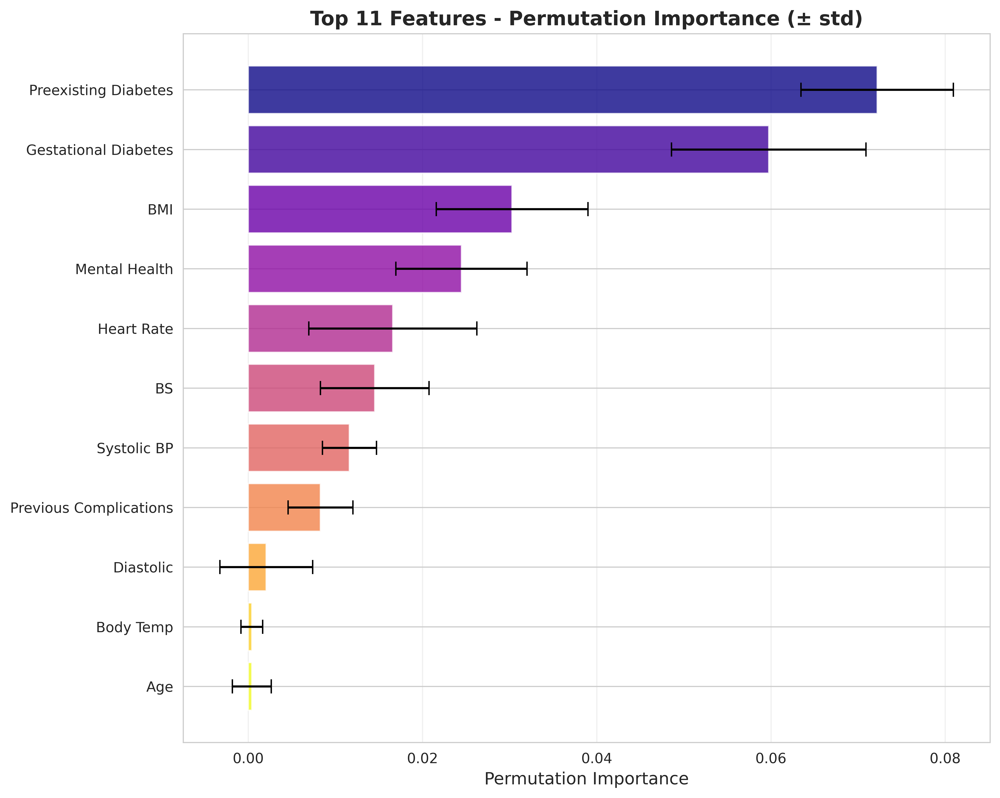

In [22]:
# ============================================================
# ✅ 16. PERMUTATION IMPORTANCE (Model-Agnostic)
# ============================================================
# Dependencies: final_pipe, X_test_transformed, y_test, feature_names, best_model_name, plot_dir (from Steps 13, 15, 2)
# Outputs: perm_importance_df (saved as CSV)

print(f"\n{'='*60}")
print("PERMUTATION IMPORTANCE ANALYSIS")
print("="*60)
print("Computing permutation importance (this may take a moment)...")

trained_model = final_pipe.named_steps['model']

perm_importance = permutation_importance(
    trained_model, X_test_transformed, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_indices = np.argsort(perm_importance.importances_mean)[::-1]
top_n_perm = min(20, len(feature_names))
top_perm_indices = perm_indices[:top_n_perm]

perm_importance_df = pd.DataFrame({
    'Feature': [feature_names[i] for i in top_perm_indices],
    'Importance Mean': perm_importance.importances_mean[top_perm_indices],
    'Importance Std': perm_importance.importances_std[top_perm_indices]
})

print(f"\nTop {top_n_perm} Features by Permutation Importance:")
display(perm_importance_df)

perm_importance_df.to_csv("/content/permutation_importance.csv", index=False)
print("✅ Permutation importance saved to: /content/permutation_importance.csv")

plt.figure(figsize=(10, 8))
colors = plt.cm.plasma(np.linspace(0, 1, len(top_perm_indices)))
y_pos = np.arange(len(top_perm_indices))

plt.barh(y_pos, perm_importance.importances_mean[top_perm_indices],
        xerr=perm_importance.importances_std[top_perm_indices],
        color=colors, alpha=0.8, ecolor='black', capsize=5)
plt.yticks(y_pos, [feature_names[i] for i in top_perm_indices])
plt.xlabel('Permutation Importance', fontsize=12)
plt.title(f'Top {top_n_perm} Features - Permutation Importance (± std)',
         fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{plot_dir}/12_permutation_importance.png", dpi=600, bbox_inches='tight')
print("✅ Saved: 12_permutation_importance.png")
plt.show()


SHAP (SHapley Additive exPlanations) ANALYSIS
Computing SHAP values (this may take a few moments)...
✅ SHAP values computed successfully!

📊 Generating SHAP Summary Plot...
✅ Saved: 13_shap_summary.png


<Figure size 6000x4800 with 0 Axes>

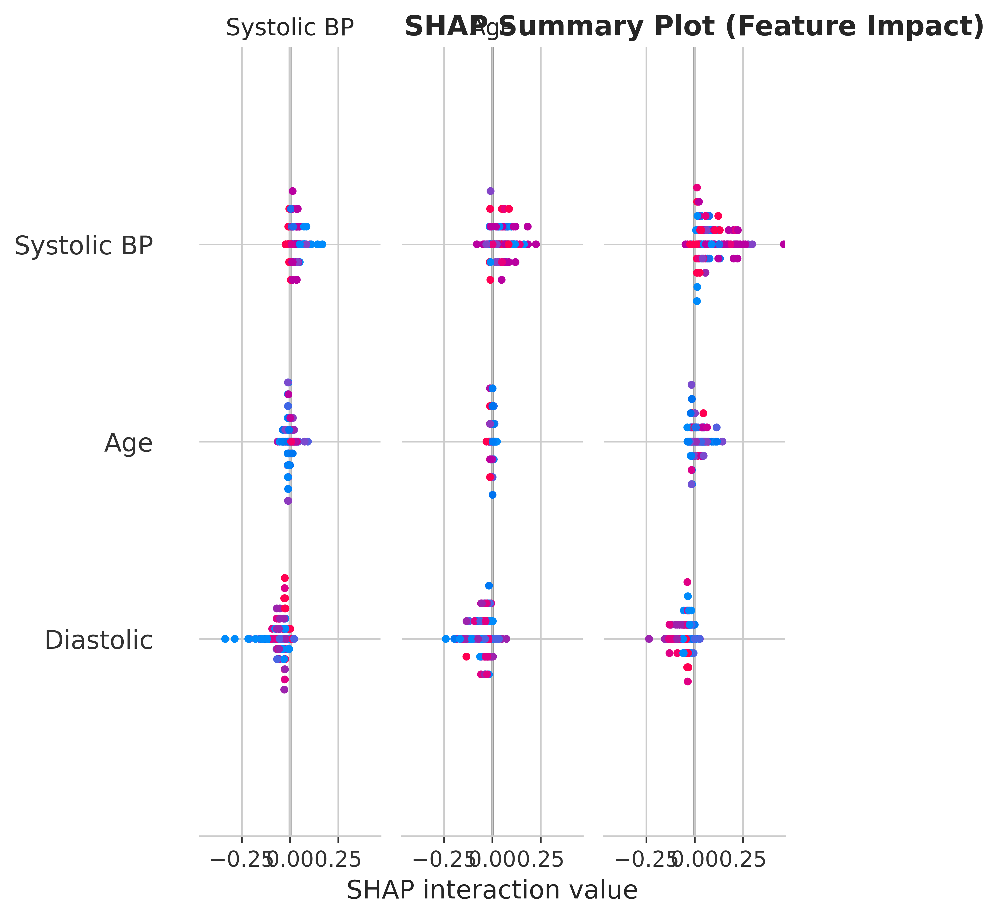


📊 Generating SHAP Bar Plot...
✅ Saved: 14_shap_bar.png


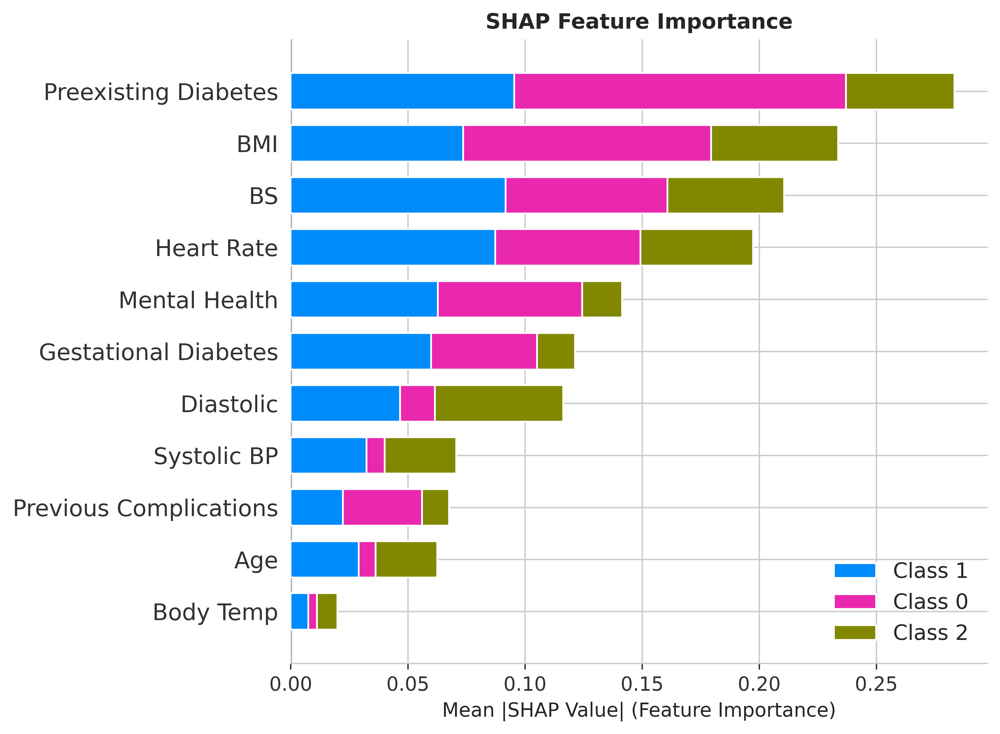


📊 Generating SHAP Waterfall Plot for Sample Prediction...
⚠️ SHAP analysis failed: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (11, 3)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.
This is normal for some models. Permutation importance is still available.


<Figure size 6000x4800 with 0 Axes>

In [23]:
# ============================================================
# ✅ 17. SHAP ANALYSIS (Advanced Explainability)
# ============================================================
# Dependencies: final_pipe, X_train_resampled, X_test_transformed, y_train_resampled, feature_names, best_model_name, plot_dir (from Steps 13, 15, 2)
# Outputs: shap_importance_df (saved as CSV)

print(f"\n{'='*60}")
print("SHAP (SHapley Additive exPlanations) ANALYSIS")
print("="*60)
print("Computing SHAP values (this may take a few moments)...")

try:
    max_samples = min(100, len(X_test_transformed))
    X_shap = X_test_transformed[:max_samples]

    trained_model = final_pipe.named_steps['model']

    if best_model_name in ['Random Forest', 'XGBoost', 'Gradient Boosting']:
        explainer = shap.TreeExplainer(trained_model)
        shap_values = explainer.shap_values(X_shap)
    else:
        explainer = shap.KernelExplainer(
            trained_model.predict_proba,
            shap.sample(X_train_resampled, 100)
        )
        shap_values = explainer.shap_values(X_shap)

    if isinstance(shap_values, list):
        shap_values_combined = shap_values[0]
    else:
        shap_values_combined = shap_values

    print("✅ SHAP values computed successfully!")

    # 1. SHAP Summary Plot (Beeswarm)
    print("\n📊 Generating SHAP Summary Plot...")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_combined, X_shap,
                     feature_names=feature_names, show=False)
    plt.title('SHAP Summary Plot (Feature Impact)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{plot_dir}/13_shap_summary.png", dpi=600, bbox_inches='tight')
    print("✅ Saved: 13_shap_summary.png")
    plt.show()

    # 2. SHAP Bar Plot
    print("\n📊 Generating SHAP Bar Plot...")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_combined, X_shap,
                     feature_names=feature_names, plot_type="bar", show=False)
    plt.xlabel("Mean |SHAP Value| (Feature Importance)", fontsize=11)
    plt.title('SHAP Feature Importance', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{plot_dir}/14_shap_bar.png", dpi=600, bbox_inches='tight')
    print("✅ Saved: 14_shap_bar.png")
    plt.show()

    # 3. SHAP Waterfall Plot
    print("\n📊 Generating SHAP Waterfall Plot for Sample Prediction...")

    if isinstance(shap_values, list):
        shap_exp = shap.Explanation(
            values=shap_values_combined[0],
            base_values=explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[0],
            data=X_shap[0],
            feature_names=feature_names
        )
    else:
        shap_exp = shap.Explanation(
            values=shap_values_combined[0],
            base_values=explainer.expected_value,
            data=X_shap[0],
            feature_names=feature_names
        )

    plt.figure(figsize=(10, 8))
    shap.waterfall_plot(shap_exp, show=False)
    plt.title('SHAP Waterfall Plot (Single Prediction Explanation)',
             fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{plot_dir}/15_shap_waterfall.png", dpi=600, bbox_inches='tight')
    print("✅ Saved: 15_shap_waterfall.png")
    plt.show()

    # 4. SHAP Dependence Plot
    top_feature_idx = np.argmax(np.abs(shap_values_combined).mean(axis=0))
    print(f"\n📊 Generating SHAP Dependence Plot for '{feature_names[top_feature_idx]}'...")

    plt.figure(figsize=(10, 6))
    shap.dependence_plot(top_feature_idx, shap_values_combined, X_shap,
                        feature_names=feature_names, show=False)
    plt.title(f'SHAP Dependence Plot - {feature_names[top_feature_idx]}',
             fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{plot_dir}/16_shap_dependence.png", dpi=600, bbox_inches='tight')
    print("✅ Saved: 16_shap_dependence.png")
    plt.show()

    # SHAP Importance DataFrame
    shap_importance = np.abs(shap_values_combined).mean(axis=0)
    shap_indices = np.argsort(shap_importance)[::-1]
    top_n_shap = min(20, len(feature_names))

    shap_importance_df = pd.DataFrame({
        'Feature': [feature_names[i] for i in shap_indices[:top_n_shap]],
        'SHAP Importance': shap_importance[shap_indices[:top_n_shap]]
    })

    print(f"\nTop {top_n_shap} Features by SHAP Importance:")
    display(shap_importance_df)

    shap_importance_df.to_csv("/content/shap_importance.csv", index=False)
    print("✅ SHAP importance saved to: /content/shap_importance.csv")

except Exception as e:
    print(f"⚠️ SHAP analysis failed: {str(e)}")
    print("This is normal for some models. Permutation importance is still available.")

In [24]:
# ============================================================
# ✅ 18. Summary Report
# ============================================================
# Dependencies: df, class_labels, n_classes, best_model_name, mean_scores, accuracy, precision, recall, f1, plot_dir (from Steps 3, 4, 7, 13, 2)
# Outputs: None (saves summary report as text file)

print(f"\n{'='*60}")
print("✅ COMPLETE ANALYSIS FINISHED!")
print("="*60)
print("\n📁 Files Saved:")
print("  CSV Files:")
print("    • /content/model_comparison_table.csv")
print("    • /content/feature_importance.csv (if tree-based model)")
print("    • /content/permutation_importance.csv")
print("    • /content/shap_importance.csv")
print(f"\n  📊 Plots Saved in: {plot_dir}/")
print("    • 01_target_distribution.png")
print("    • 02_feature_distributions.png")
print("    • 03_correlation_heatmap.png")
print("    • 04_boxplots_outliers.png")
print("    • 05_model_comparison.png")
print("    • 06_cv_heatmap.png")
print("    • 07_confusion_matrix.png")
print("    • 08_roc_curve.png")
print("    • 09_prediction_distribution.png")
print("    • 10_feature_importance.png (if tree-based)")
print("    • 11_cumulative_importance.png (if tree-based)")
print("    • 12_permutation_importance.png")
print("    • 13_shap_summary.png")
print("    • 14_shap_bar.png")
print("    • 15_shap_waterfall.png")
print("    • 16_shap_dependence.png")
print("\n🎉 Your analysis is ready for publication!")
print(f"📥 Download all plots from: {plot_dir}/")

# Create summary report
summary_report = f"""
╔══════════════════════════════════════════════════════════╗
║          MATERNAL HEALTH RISK PREDICTION SUMMARY         ║
╚══════════════════════════════════════════════════════════╝

📊 Dataset Information:
   • Total Samples: {df.shape[0]}
   • Features: {df.shape[1] - 1}
   • Classes: {n_classes} ({', '.join(map(str, class_labels))})
   • Train/Test Split: 80/20

🏆 Best Model: {best_model_name}
   • Cross-Validation {metric_name}: {mean_scores[best_model_name]:.4f}
   • Test Accuracy: {accuracy:.4f}
   • Test Precision: {precision:.4f}
   • Test Recall: {recall:.4f}
   • Test F1-Score: {f1:.4f}

📁 Output Files Generated: {16 if best_model_name in ['Random Forest', 'XGBoost'] else 14} plots + 4 CSV files

✅ Analysis Complete!
"""

print(summary_report)

with open(f"{plot_dir}/analysis_summary.txt", "w") as f:
    f.write(summary_report)
print(f"📄 Summary report saved to: {plot_dir}/analysis_summary.txt")


✅ COMPLETE ANALYSIS FINISHED!

📁 Files Saved:
  CSV Files:
    • /content/model_comparison_table.csv
    • /content/feature_importance.csv (if tree-based model)
    • /content/permutation_importance.csv
    • /content/shap_importance.csv

  📊 Plots Saved in: /content/plots/
    • 01_target_distribution.png
    • 02_feature_distributions.png
    • 03_correlation_heatmap.png
    • 04_boxplots_outliers.png
    • 05_model_comparison.png
    • 06_cv_heatmap.png
    • 07_confusion_matrix.png
    • 08_roc_curve.png
    • 09_prediction_distribution.png
    • 10_feature_importance.png (if tree-based)
    • 11_cumulative_importance.png (if tree-based)
    • 12_permutation_importance.png
    • 13_shap_summary.png
    • 14_shap_bar.png
    • 15_shap_waterfall.png
    • 16_shap_dependence.png

🎉 Your analysis is ready for publication!
📥 Download all plots from: /content/plots/

╔══════════════════════════════════════════════════════════╗
║          MATERNAL HEALTH RISK PREDICTION SUMMARY         ║